In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import BORDERS, LAND, OCEAN
from ipywidgets import interact, IntSlider
from matplotlib.widgets import Slider

from ml_baselines.features import open_features
from ml_baselines.config import Config

cfg = Config()

In [3]:
site = "MHD"
df_features = open_features(site, 2000, 2001)

print("total features: ", len(df_features.columns))

total features:  273


In [30]:
def variables_points_timesteps(columns):
    
    variables_0d = ["hour_of_day"]
    variables = []
    points = []
    timesteps = []

    for col in columns:
        if col in variables_0d:
            continue
        elif len(col.split("_")) == 3:
            var, point, timestep = col.split("_")
            variables.append(var)
            points.append(point)
            timesteps.append(timestep)
        elif len(col.split("_")) == 2:
            var, point = col.split("_")
            variables.append(var)
            points.append(point)
            timesteps.append("")

    if not len(variables) + len(variables_0d) == len(columns):
        raise ValueError("Have you accounted for all of the zero-dimension variables?")

    variables = sorted(list(set(variables)))
    points = sorted(list(set(points)))
    timesteps = sorted(list(set(timesteps)))

    return variables_0d, variables, points, timesteps

In [31]:
variables_0d, variables, points, timesteps = variables_points_timesteps(df_features.columns)
print("Variables (0D):", variables_0d)
print("Variables:", variables)
print("Points:", points)
print("Timesteps:", timesteps)

Variables (0D): ['hour_of_day']
Variables: ['blh', 'sp', 'u10', 'u500', 'u850', 'v10', 'v500', 'v850']
Points: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '2', '3', '4', '5', '6', '7', '8', '9']
Timesteps: ['', '6h']


In [9]:
# Timeseries figure, with selector for the variable to plot
def plot_timeseries(variable,
                    point=0):
    plt.figure(figsize=(10, 5))
    plt.plot(df_features.index, df_features[variable], label=variable)
    plt.xlabel("Time")
    plt.ylabel(variable)
    plt.title(f"{variable} at {site}")
    plt.legend()
    plt.grid()
    plt.show()

# Interactive widget to select variable
variables = set([col.split('_')[0] for col in df_features.columns])
npoints = len([col for col in df_features.columns if col.startswith(list(variables)[0])])

interact(plot_timeseries, variable=variables, point=IntSlider(min=0, max=int(npoints)-1, step=1, value=0))

<Figure size 1000x500 with 0 Axes>

interactive(children=(Dropdown(description='variable', options=('u10', 'hour', 'sp', 'v850', 'u500', 'v500', '…

<function __main__.plot_timeseries(variable, point=0)>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

...

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [ ]:
def interactive_wind_plot(time_idx=0):

    wind_variables=["u10", "v10"]
    
    # Get the grid coordinates
    lats = cfg.lats_grid + cfg.site_coords_dict[site][0]
    lons = cfg.lons_grid + cfg.site_coords_dict[site][1]
    
    # Extract u and v components
    u_components = [df_features.iloc[time_idx][f"{wind_variables[0]}_{i}"] for i in range(17)]
    v_components = [df_features.iloc[time_idx][f"{wind_variables[1]}_{i}"] for i in range(17)]
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Plot wind vectors
    quiver = ax.quiver(lons, lats, u_components, v_components, 
                       scale=100, scale_units='width', width=0.003,
                       color='blue', alpha=0.7)
    
    # Add reference arrow
    ax.quiverkey(quiver, 0.9, 0.95, 10, '10 m/s', labelpos='E')
    
    # Customize the plot
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude') 
    ax.set_title(f'Wind Vectors at Grid Points (Time: {df_features.index[time_idx]})')
    ax.grid(True, alpha=0.3)
    
    # Add grid point markers
    ax.scatter(lons, lats, c='red', s=30, zorder=5, alpha=0.8)
    
    # Add map background
    ax.coastlines()
    ax.add_feature(BORDERS, linestyle=':')
    ax.add_feature(LAND, edgecolor='black', alpha=0.5)
    ax.add_feature(OCEAN, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
time_slider = IntSlider(min=0, max=len(df_features)-1, step=1, value=0, description='Time:')
interact(interactive_wind_plot, time_idx=time_slider)

interactive(children=(IntSlider(value=0, description='Time:', max=17543), Output()), _dom_classes=('widget-int…

<function __main__.interactive_wind_plot(time_idx=0)>

/Users/chxmr/opt/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/chxmr/opt/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


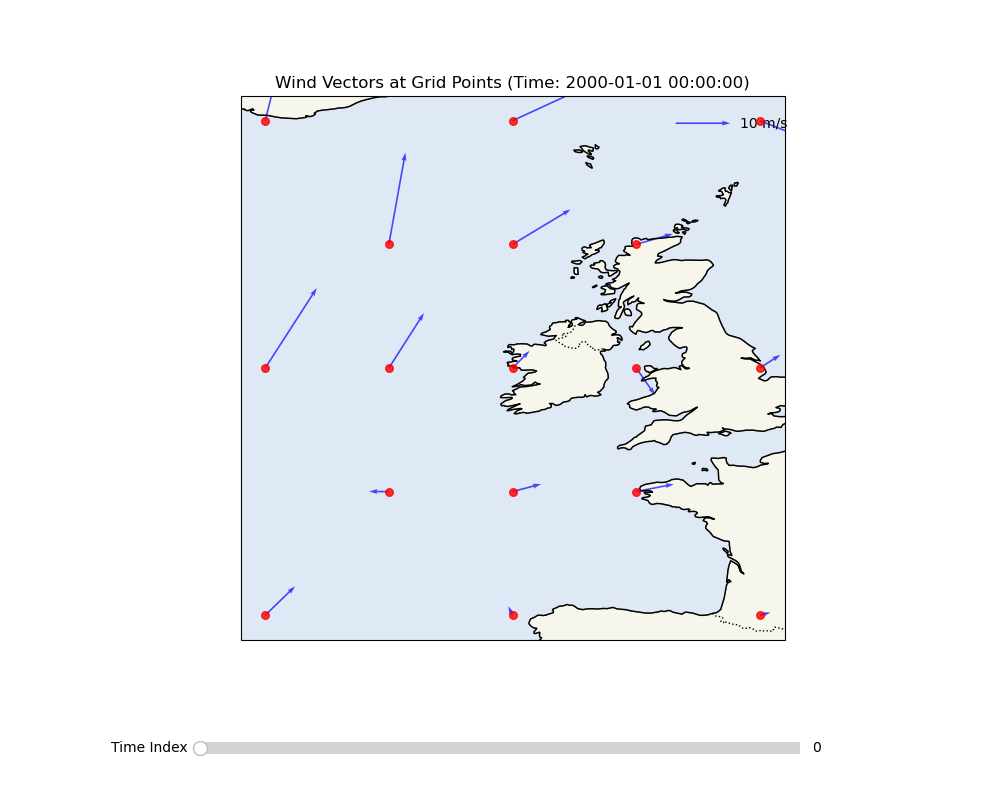

In [6]:
def create_animated_wind_plot(wind_variables=["u10", "v10"]):
    # Get the grid coordinates
    lats = cfg.lats_grid + cfg.site_coords_dict[site][0]
    lons = cfg.lons_grid + cfg.site_coords_dict[site][1]
    
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Add map features
    ax.coastlines()
    ax.add_feature(BORDERS, linestyle=':')
    ax.add_feature(LAND, edgecolor='black', alpha=0.5)
    ax.add_feature(OCEAN, alpha=0.3)
    ax.grid(True, alpha=0.3)
    
    # Initial time index
    initial_time_idx = 0
    
    # Extract initial u and v components
    u_components = [df_features.iloc[initial_time_idx][f"{wind_variables[0]}_{i}"] for i in range(17)]
    v_components = [df_features.iloc[initial_time_idx][f"{wind_variables[1]}_{i}"] for i in range(17)]
    
    # Create initial quiver plot
    quiver = ax.quiver(lons, lats, u_components, v_components, 
                       scale=100, scale_units='width', width=0.003,
                       color='blue', alpha=0.7)
    
    # Add reference arrow
    ax.quiverkey(quiver, 0.9, 0.95, 10, '10 m/s', labelpos='E')
    
    # Add grid point markers
    scatter = ax.scatter(lons, lats, c='red', s=30, zorder=5, alpha=0.8)
    
    # Set title
    title = ax.set_title(f'Wind Vectors at Grid Points (Time: {df_features.index[initial_time_idx]})')
    
    # Customize the plot
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    # Make room for slider
    plt.subplots_adjust(bottom=0.2)
    
    # Create slider
    ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
    slider = Slider(ax_slider, 'Time Index', 0, len(df_features)-1, 
                    valinit=initial_time_idx, valfmt='%d')
    
    # Update function for slider
    def update_plot(val):
        time_idx = int(slider.val)
        
        # Get new u and v components
        u_new = [df_features.iloc[time_idx][f"{wind_variables[0]}_{i}"] for i in range(17)]
        v_new = [df_features.iloc[time_idx][f"{wind_variables[1]}_{i}"] for i in range(17)]
        
        # Update quiver plot
        quiver.set_UVC(u_new, v_new)
        
        # Update title
        title.set_text(f'Wind Vectors at Grid Points (Time: {df_features.index[time_idx]})')
        
        # Redraw
        fig.canvas.draw()
    
    # Connect slider to update function
    slider.on_changed(update_plot)
    
    plt.show()
    
    return fig, slider

# Create the animated plot
fig, slider = create_animated_wind_plot(wind_variables=["u10", "v10"])